In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib as mpl
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import json

mpl.rcParams.update({
    'axes.titlesize'   : 0,        # no title
    'axes.labelsize'   : 14,       # x and y axis labels
    'xtick.labelsize'  : 12,       # x tick labels
    'ytick.labelsize'  : 12,       # y tick labels
    'legend.fontsize'  : 12,
    'font.size'        : 12,      
})

In [2]:
df = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/main_data.csv", encoding="utf-8")

/tmp/ipykernel_115352/2256054893.py:1: DtypeWarning: Columns (0,4,5,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/main_data.csv", encoding="utf-8")


In [3]:
import re
from tqdm.auto import tqdm

us_lex = pd.read_csv("us_vocabulary.csv")["term"].dropna().str.lower().tolist()
them_lex = pd.read_csv("them_vocabulary.csv")["term"].dropna().str.lower().tolist()

In [4]:
def build_pattern(terms):
    escaped = [re.escape(t) for t in terms]
    pattern = r"\b(?:{})\b".format("|".join(escaped))
    return re.compile(pattern, flags=re.IGNORECASE)

us_pattern = build_pattern(us_lex)
them_pattern = build_pattern(them_lex)



In [5]:
def count_matches(text, pattern):
    if not isinstance(text, str):
        return 0
    return len(pattern.findall(text))


In [6]:
df["us_count"] = df["text"].apply(lambda x: count_matches(x, us_pattern))
df["them_count"] = df["text"].apply(lambda x: count_matches(x, them_pattern))



In [7]:
def word_count(text):
    if not isinstance(text, str):
        return 0
    return len(re.findall(r"\b\w+\b", text))

df["n_words"] = df["text"].apply(word_count)

df["us_per_100w"] = 100 * df["us_count"] / df["n_words"].replace(0, 1)
df["them_per_100w"] = 100 * df["them_count"] / df["n_words"].replace(0, 1)


In [8]:
df["us_them_intensity_count"] = df["us_per_100w"] + df["them_per_100w"]


In [9]:
df["us_them_diff_count"] = df["us_per_100w"] - df["them_per_100w"]



In [10]:
df[["us_per_100w", "them_per_100w", "us_them_intensity_count"]].describe()

df.groupby("Populism")[["us_per_100w", "them_per_100w"]].mean()


,us_per_100w,them_per_100w
Populism,,
0,3.412734,1.048714
1,3.553838,1.485374


In [11]:
df["election_year"] = df["election_date"].astype(str).str[:4].astype("Int64")



In [12]:
set(df["election_year"])

{1952,
 1956,
 1960,
 1964,
 1968,
 1972,
 1976,
 1980,
 1984,
 1988,
 1992,
 1996,
 2000,
 2004,
 2008,
 2012,
 2016,
 2020}

In [13]:
df["person"] = (
    df["person"].astype(str)
    + "_"
    + df["election_year"].astype(str)
)


In [14]:
df_pop = df[df["Populism"] == 1]
df_non = df[df["Populism"] == 0]

n_pop = len(df_pop)
print("Populist rows:", n_pop)

Populist rows: 1861


In [15]:
df_non_sampled = df_non.sample(
    n=n_pop,
    random_state=42  # for reproducibility
)

# Combine
df_balanced = pd.concat([df_pop, df_non_sampled], axis=0).reset_index(drop=True)

print(df_balanced["Populism"].value_counts())


1    1861
0    1861
Name: Populism, dtype: int64


# "US" rhetoric

In [16]:
import statsmodels.api as sm

y = df_balanced["us_per_100w"]
X = df_balanced[["Populism"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:            us_per_100w   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     2.715
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0995
Time:                        14:42:03   Log-Likelihood:                -9328.5
No. Observations:                3722   AIC:                         1.866e+04
Df Residuals:                    3720   BIC:                         1.867e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.3935      0.070     48.321      0.0

In [17]:
import numpy as np
coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["us_per_100w"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit(cov_type="HC3")
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)


(0.13437744144330077, 0.0670860142715183)

In [18]:
import statsmodels.formula.api as smf

# Make sure types are correct
df_balanced["Populism"] = df_balanced["Populism"].astype(int)
df_balanced["prior_president"] = df_balanced["prior_president"].astype(int)

# Drop missing values in required columns
df_mixed = df_balanced.dropna(
    subset=["us_per_100w", "Populism", "prior_president", "person"]
)


In [19]:
mixed = smf.mixedlm(
    formula="us_per_100w ~ Populism + prior_president",
    data=df_mixed,
    groups=df_mixed["person"]
)

mixed_res = mixed.fit(method="lbfgs")
print(mixed_res.summary())


                 Mixed Linear Model Regression Results
Model:                 MixedLM      Dependent Variable:      us_per_100w
No. Observations:      3722         Method:                  REML       
No. Groups:            34           Scale:                   8.5218     
Min. group size:       17           Log-Likelihood:          inf        
Max. group size:       367          Converged:               Yes        
Mean group size:       109.5                                            
------------------------------------------------------------------------
                Coef.   Std.Err.    z   P>|z|     [0.025       0.975]   
------------------------------------------------------------------------
Intercept       0.391 3159347.588 0.000 1.000  -6192207.096  6192207.877
Populism        0.288       0.121 2.376 0.018         0.050        0.525
prior_president 0.043 6357410.737 0.000 1.000 -12460296.036 12460296.122
Group Var       0.000                                                

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  w

In [20]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

fe = smf.ols(
    "us_per_100w ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe.summary())


                            OLS Regression Results                            
Dep. Variable:            us_per_100w   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     5.044
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0315
Time:                        14:42:06   Log-Likelihood:                -9267.2
No. Observations:                3722   AIC:                         1.860e+04
Df Residuals:                    3687   BIC:                         1.882e+04
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


# "Them" Rhetoric

In [21]:
import statsmodels.api as sm

y = df_balanced["them_per_100w"]
X = df_balanced[["Populism"]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type="HC3")
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:          them_per_100w   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     54.26
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           2.15e-13
Time:                        14:42:06   Log-Likelihood:                -7527.8
No. Observations:                3722   AIC:                         1.506e+04
Df Residuals:                    3720   BIC:                         1.507e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0435      0.040     26.410      0.0

In [22]:
import numpy as np
coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["them_per_100w"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit(cov_type="HC3")
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)


(0.43229601352996894, 0.03975452330366471)

In [23]:
import statsmodels.formula.api as smf

# Make sure types are correct
df_balanced["Populism"] = df_balanced["Populism"].astype(int)
df_balanced["prior_president"] = df_balanced["prior_president"].astype(int)

# Drop missing values in required columns
df_mixed = df_balanced.dropna(
    subset=["them_per_100w", "Populism", "prior_president", "person"]
)

In [24]:
mixed = smf.mixedlm(
    formula="them_per_100w ~ Populism + prior_president",
    data=df_mixed,
    groups=df_mixed["person"]
)

mixed_res = mixed.fit(method="lbfgs")
print(mixed_res.summary())


                 Mixed Linear Model Regression Results
Model:                 MixedLM     Dependent Variable:     them_per_100w
No. Observations:      3722        Method:                 REML         
No. Groups:            34          Scale:                  3.2175       
Min. group size:       17          Log-Likelihood:         inf          
Max. group size:       367         Converged:              Yes          
Mean group size:       109.5                                            
------------------------------------------------------------------------
                Coef.    Std.Err.    z    P>|z|    [0.025       0.975]  
------------------------------------------------------------------------
Intercept       -0.233 1941305.858 -0.000 1.000 -3804889.798 3804889.332
Populism         0.311       0.074  4.184 0.000        0.165       0.457
prior_president -0.025 3906401.042 -0.000 1.000 -7656405.376 7656405.325
Group Var        0.000                                               

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1635: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2055: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2246: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2262: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  w

In [25]:
import statsmodels.formula.api as smf
import statsmodels.api as sm

fe = smf.ols(
    "them_per_100w ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe.summary())

                            OLS Regression Results                            
Dep. Variable:          them_per_100w   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     4.391
Date:                Mon, 27 Apr 2026   Prob (F-statistic):             0.0439
Time:                        14:42:08   Log-Likelihood:                -7454.6
No. Observations:                3722   AIC:                         1.498e+04
Df Residuals:                    3687   BIC:                         1.520e+04
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


In [26]:
df.to_csv("prof_llm_usthem.csv", encoding="utf-8", index=False)

# LLM embedding approach

In [27]:
dfllm = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_usthem_with_similarity.csv", encoding="utf-8")

/tmp/ipykernel_115352/876887227.py:1: DtypeWarning: Columns (0,4,5,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dfllm = pd.read_csv("/home/scc/sergio.zanotto/bin/badmanners/vulgarity/prof_llm_usthem_with_similarity.csv", encoding="utf-8")


In [28]:
df_pop = dfllm[dfllm["Populism"] == 1]
df_non = dfllm[dfllm["Populism"] == 0]

n_pop = len(df_pop)
print("Populist rows:", n_pop)

Populist rows: 1861


In [29]:
df_non_sampled = df_non.sample(
    n=n_pop,
    random_state=42  # for reproducibility
)

# Combine
df_balanced = pd.concat([df_pop, df_non_sampled], axis=0).reset_index(drop=True)

print(df_balanced["Populism"].value_counts())

1    1861
0    1861
Name: Populism, dtype: int64


# "US" rhetoric with embeddings

In [30]:
df_balanced[["us_sim_top10", "us_sim_max"]].describe()
df_balanced[["us_sim_top10", "us_sim_max"]].corr()


,us_sim_top10,us_sim_max
us_sim_top10,1.000000,0.605847
us_sim_max,0.605847,1.000000


In [31]:
for var in ["us_sim_top10", "us_sim_max"]:
    res = smf.ols(
        f"{var} ~ Populism + prior_president + C(person)",
        data=df_balanced
    ).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})
    print(var, res.params["Populism"], res.pvalues["Populism"])


us_sim_top10 0.004214017397453165 0.1673907376994177
us_sim_max 0.022365855756694083 5.9752108423144205e-06


In [32]:
import statsmodels.api as sm

y = df_balanced["us_sim_top10"]
X = sm.add_constant(df_balanced[["Populism"]])

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:           us_sim_top10   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     16.41
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.20e-05
Time:                        14:42:14   Log-Likelihood:                 6418.2
No. Observations:                3722   AIC:                        -1.283e+04
Df Residuals:                    3720   BIC:                        -1.282e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0994      0.001     94.392      0.0

In [33]:
import numpy as np

coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["us_sim_top10"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit()
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

(0.006243902341370218, 0.0010396943508784757)

In [34]:
import statsmodels.api as sm

y = df_balanced["us_sim_top10"]

X = df_balanced[["Populism", "prior_president"]]
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:           us_sim_top10   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     9.250
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           9.83e-05
Time:                        14:42:16   Log-Likelihood:                 6419.3
No. Observations:                3722   AIC:                        -1.283e+04
Df Residuals:                    3719   BIC:                        -1.281e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0984      0.001     

In [35]:
import statsmodels.formula.api as smf

fe_person = smf.ols(
    "us_sim_top10 ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe_person.summary())

                            OLS Regression Results                            
Dep. Variable:           us_sim_top10   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                    0.1004
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.753
Time:                        14:42:16   Log-Likelihood:                 6499.0
No. Observations:                3722   AIC:                        -1.293e+04
Df Residuals:                    3687   BIC:                        -1.271e+04
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


# "Them" rhetoric with embeddings

In [36]:
df_balanced[["them_sim_top10", "them_sim_max"]].describe()
df_balanced[["them_sim_top10", "them_sim_max"]].corr()

,them_sim_top10,them_sim_max
them_sim_top10,1.000000,0.730999
them_sim_max,0.730999,1.000000


In [37]:
for var in ["them_sim_top10", "them_sim_max"]:
    res = smf.ols(
        f"{var} ~ Populism + prior_president + C(person)",
        data=df_balanced
    ).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})
    print(var, res.params["Populism"], res.pvalues["Populism"])


them_sim_top10 0.012913982682596097 3.0068381108886183e-07
them_sim_max 0.043821568509723546 1.511634842651031e-16


In [38]:
import statsmodels.api as sm

y = df_balanced["them_sim_top10"]
X = sm.add_constant(df_balanced[["Populism"]])

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:         them_sim_top10   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     188.9
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           5.79e-42
Time:                        14:42:16   Log-Likelihood:                 6760.5
No. Observations:                3722   AIC:                        -1.352e+04
Df Residuals:                    3720   BIC:                        -1.350e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0669      0.001     73.974      0.0

In [39]:
import numpy as np

coefs = []

for seed in range(100):
    df_non_sampled = df_non.sample(n=n_pop, random_state=seed)
    df_bal = pd.concat([df_pop, df_non_sampled])

    y = df_bal["them_sim_top10"]
    X = sm.add_constant(df_bal[["Populism"]])

    res = sm.OLS(y, X).fit()
    coefs.append(res.params["Populism"])

np.mean(coefs), np.std(coefs)

(0.01772782342672382, 0.0008895003604723552)

In [40]:
import statsmodels.api as sm

y = df_balanced["them_sim_top10"]

X = df_balanced[["Populism", "prior_president"]]
X = sm.add_constant(X)

ols = sm.OLS(y, X).fit(cov_type="HC3")
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:         them_sim_top10   R-squared:                       0.056
Model:                            OLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     107.6
Date:                Mon, 27 Apr 2026   Prob (F-statistic):           3.67e-46
Time:                        14:42:19   Log-Likelihood:                 6774.9
No. Observations:                3722   AIC:                        -1.354e+04
Df Residuals:                    3719   BIC:                        -1.353e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.0702      0.001     

In [41]:
import statsmodels.formula.api as smf

fe_person = smf.ols(
    "them_sim_top10 ~ Populism + prior_president + C(person)",
    data=df_balanced
).fit(cov_type="cluster", cov_kwds={"groups": df_balanced["person"]})

print(fe_person.summary())

                            OLS Regression Results                            
Dep. Variable:         them_sim_top10   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.154
Method:                 Least Squares   F-statistic:                     1.096
Date:                Mon, 27 Apr 2026   Prob (F-statistic):              0.303
Time:                        14:42:19   Log-Likelihood:                 6997.6
No. Observations:                3722   AIC:                        -1.393e+04
Df Residuals:                    3687   BIC:                        -1.371e+04
Df Model:                          34                                         
Covariance Type:              cluster                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

/usr/local/jupyterhub/lib64/python3.10/site-packages/statsmodels/base/model.py:1896: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 35, but rank is 1
  warnings.warn('covariance of constraints does not have full '


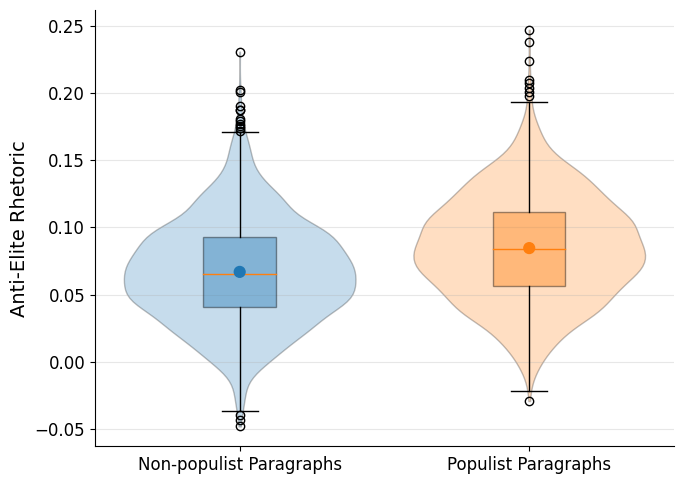

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

#  Violin + box + mean plot (Populism on X, them-use on Y) ---
# Ensure no missing values for the plotted variables
plot_df = df_balanced[["Populism", "them_sim_top10"]].dropna()

groups = [0, 1]
labels = ["Non-populist Paragraphs", "Populist Paragraphs"]
colors = ["tab:blue", "tab:orange"]

data = [plot_df.loc[plot_df["Populism"] == g, "them_sim_top10"].to_numpy() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5))

# Violin
vp = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.25)
    body.set_edgecolor("black")

# Boxplot overlay
bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=True
)

# Color boxplots
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# Mean points
means = [np.mean(d) if len(d) else np.nan for d in data]
ax.scatter([1, 2], means, s=60, color=colors, zorder=3)

# Labels and styling
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel("")
ax.set_ylabel("Anti-Elite Rhetoric")


ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("Anti-Elite_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()

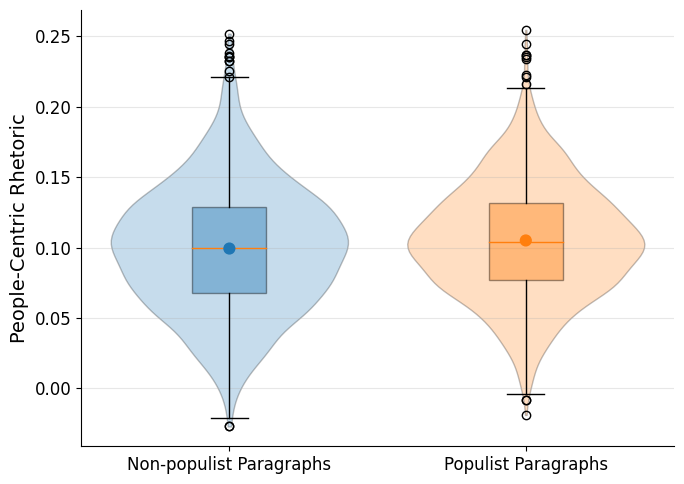

In [43]:
#  Violin + box + mean plot (Populism on X, them-use on Y) ---
# Ensure no missing values for the plotted variables
plot_df = df_balanced[["Populism", "us_sim_top10"]].dropna()

groups = [0, 1]
labels = ["Non-populist Paragraphs", "Populist Paragraphs"]
colors = ["tab:blue", "tab:orange"]

data = [plot_df.loc[plot_df["Populism"] == g, "us_sim_top10"].to_numpy() for g in groups]

fig, ax = plt.subplots(figsize=(7, 5))

# Violin
vp = ax.violinplot(
    data,
    positions=[1, 2],
    widths=0.8,
    showmeans=False,
    showmedians=False,
    showextrema=False
)

# Color violins
for body, color in zip(vp["bodies"], colors):
    body.set_facecolor(color)
    body.set_alpha(0.25)
    body.set_edgecolor("black")

# Boxplot overlay
bp = ax.boxplot(
    data,
    positions=[1, 2],
    widths=0.25,
    patch_artist=True,
    showfliers=True
)

# Color boxplots
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.4)

# Mean points
means = [np.mean(d) if len(d) else np.nan for d in data]
ax.scatter([1, 2], means, s=60, color=colors, zorder=3)

# Labels and styling
ax.set_xticks([1, 2])
ax.set_xticklabels(labels)
ax.set_xlabel("")
ax.set_ylabel("People-Centric Rhetoric")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("People-Centric_violinplot.png", dpi=300, bbox_inches="tight")
plt.show()